In [64]:
import numpy as np 
import jax 
import jax.numpy as jnp
import matplotlib.pyplot as plt
import scipy
import importlib 

from typing import Tuple
from src.data_structures import Inputs, Outputs

import projects.trial_to_trial_variability.spec as project_spec
importlib.reload(project_spec)
from projects.trial_to_trial_variability.spec import load_and_process_data, train_test_split


In [ ]:

def load_and_process_data(
    data_path: str, 
    # ---- ALL SUBSEQUENT PARAMS MUST BE SPECIFIED IN THE CONFIG FILE ----
    random_seed: int = 42,
    train_to_test_split_ratio: float = 0.5,
    conc_threshold: float = 0.55,
) -> Tuple[Inputs, Outputs]:
    """
    Load and preprocess neural data and return data in the form of 
    Inputs and Outputs objects. 
    
    Parameters
    ----------
    data_path : str
        Path to the .npy file containing neural data.
    random_seed : int
        Random seed for reproducibility of source / target cell split 
    train_to_test_split_ratio : float
        Ratio of source cells to target cells (e.g. 0.7 means 70% of cells are in the training pouplation)     

    Returns
    -------
    X: Inputs object - has shape (2, n_source_cells, n_time) where sample 0 is a training population 
        and sample 1 is the held-out population for testing 
    Y: Outputs object - has shape (2, n_target_cells, n_time) where sample 0 is the training population 
        and sample 1 is the held-out population for testing
    """
    # data_path = "/home/dabin/data/jacob_gratings_202507/parsed/"
    mouse = 'BZ015'
    date = '2025-07-03'
    # mouse = 'BZ016'
    # date = '2025-06-24'
    exp_nums = [2, 3, 5] if mouse == 'BZ015' else [1]

    dataset_name = f'jacob_{mouse}_{date}'

    data_dirs = []
    metadata_dirs = []

    for n_exp in exp_nums:
        spks_path = f"{data_path}/{mouse}_{date}_{n_exp}"
        stims_path = f"{data_path}/{mouse}_{date}_{n_exp}"
        spks_file = f"{spks_path}/{mouse}_{date}_{n_exp}_dspikes.npy"
        stims_file = f"{stims_path}/{date}_{n_exp}_{mouse}_Block.mat"

        data_dirs.append(spks_file)
        metadata_dirs.append(stims_file)

    data_dirs, metadata_dirs = data_dirs, metadata_dirs
    responses = []
    for data_dir in data_dirs:
        response = np.load(data_dir).T
        responses.append(response)
    angles = []
    for metadata_dir in metadata_dirs:
        mat_data = scipy.io.loadmat(metadata_dir, simplify_cells=True)
        # in the single block case the first and last angles should be removed
        if 'BZ016' in metadata_dir:
            angles.append(np.array([entry['gratingOrient'] for entry in mat_data['block']['paramsValues']])[1:-1])
        else: 
            angles.append(np.array([entry['gratingOrient'] for entry in mat_data['block']['paramsValues']]))
    # remove responses where angle = 0
    for i in range(len(responses)):
        responses[i] = responses[i][:, angles[i] != 0]
        angles[i] = angles[i][angles[i] != 0]
        angles[i] = np.deg2rad(angles[i])

    # # for each repeat, reorder angles and responses
    # for i in range(len(responses)):
    #     responses[i] = responses[i][:, np.argsort(angles[i])]
    #     angles[i] = np.sort(angles[i])

    # now turn responses into an array and replace angles with any of its entries
    response = np.array(responses) # shape (n_blocks, n_cells, n_trials)
    n_blocks = response.shape[0] # n_repeats for BZ015 Which had 3 blocks, whereas BZ016 had 1 block but every trial was still repeated 3 times randomly. 
    angles = angles[0]

    response_flat = np.transpose(response, (1, 2, 0))  # n_cells x n_trials x n_blocks
    response_flat = response_flat.reshape(response_flat.shape[0], -1)  # n_cells x (n_trials*n_blocks)
    angles_flat = np.repeat(angles, n_blocks)  # now angles is (n_trials*n_blocks)
    response, angles = response_flat, angles_flat
    print(f"Response shape after flattening: {response.shape}, Angles shape after flattening: {angles.shape}")

    n_trials = response.shape[1]

    if conc_threshold is not None:
        conc = np.abs(np.sum(np.exp(2j * angles)[np.newaxis, :] * response, axis=1) / np.sum(response, axis=1))
        good_cells = np.where(conc > conc_threshold)[0]

        print(f"Filtering for orientation selectivity. Kept {len(good_cells)} out of {response.shape[0]} cells.")
        response = response[good_cells]

    rng = np.random.default_rng(random_seed)

    # Source/Target split for trial to trial variability 
    cell_idx = rng.permutation(response.shape[0])
    n_source_cells = int(train_to_test_split_ratio * response.shape[0])
    source_cells = cell_idx[:n_source_cells]
    target_cells = cell_idx[n_source_cells:]
    print(f"Train to test split ratio: {train_to_test_split_ratio}, Number of source cells: {len(source_cells)}, Number of target cells: {len(target_cells)}")

    if source_cells.size == 0 or target_cells.size == 0:
        raise ValueError("Train to test split ratio results in empty source or target cell population. Please adjust the ratio.")    

    half_source = source_cells.size // 2 
    half_target = target_cells.size // 2 
    train_source = source_cells[:half_source]
    # make sure we handle odd number of cells by putting the extra cell in the training set
    test_source = source_cells[-half_source:]
    train_target = target_cells[:half_target]
    test_target = target_cells[-half_target:]

    # TODO : think about whether z_scoring should happen after the cell and trial split or before? Currently it's after 
    X_train = response[train_source]
    X_test = response[test_source]
    Y_train = response[train_target]
    Y_test = response[test_target]
    print(f"X_train shape: {X_train.shape}, X_test shape: {X_test.shape}, Y_train shape: {Y_train.shape}, Y_test shape: {Y_test.shape}")

    # rather than zscore, just divide by the std 
    eps = 1e-12
    X_train = X_train / (X_train.std(axis=1, keepdims=True) + eps)
    X_test = X_test / (X_test.std(axis=1, keepdims=True) + eps)
    Y_train = Y_train / (Y_train.std(axis=1, keepdims=True) + eps)
    Y_test = Y_test / (Y_test.std(axis=1, keepdims=True) + eps)

    # Create Inputs object with the angles as the first (and currently only) input
    # Shape: (n_cells, 1, n_trials)
    X_dict = {}
    # create a stimulus array by tiling it by n_source number of times 
    X_dict['stimulus'] = np.tile(angles, (half_source, 1))
    X_dict['train'] = X_train
    X_dict['test'] = X_test 

    Y_dict = {}
    Y_dict['stimulus'] = np.tile(angles, (half_target, 1))
    Y_dict['train'] = Y_train
    Y_dict['test'] = Y_test
    # X = np.stack([X_train, X_test], axis=0) # (2, n_source, n_time)
    # Y = np.stack([Y_train, Y_test], axis=0) # (2, n_target, n_time)
    X = Inputs.from_dict(X_dict)
    Y = Outputs.from_dict(Y_dict)
    return X, Y

In [3]:
X, Y = load_and_process_data(
    data_path = "/home/dabin/data/jacob_gratings_202507/parsed/",
    random_seed = 42,
    train_to_test_split_ratio = 0.5,
    conc_threshold = 0.25,
)

Response shape after flattening: (15166, 3075), Angles shape after flattening: (3075,)
Filtering for orientation selectivity. Kept 649 out of 15166 cells.
Train to test split ratio: 0.5, Number of source cells: 324, Number of target cells: 325
X_train shape: (162, 3075), X_test shape: (162, 3075), Y_train shape: (162, 3075), Y_test shape: (162, 3075)


In [32]:
# read the param values from the config yaml 
import yaml
with open('projects/trial_to_trial_variability/config.yaml', 'r') as f:
    config = yaml.safe_load(f)['data_processing_params']

data = load_and_process_data(**config)

Filtering for orientation selectivity. Kept 649 out of 15166 cells.


In [33]:
X = data[0]
Y = data[1]

# X_stim = X['stimulus']
# X_train = X['train']
# X_test = X['test']

# Y_stim = Y['stimulus']
# Y_train = Y['train']
# Y_test = Y['test']

In [36]:
X.shape, Y.shape, X['train'].shape

((162, 3, 3075), (162, 3, 3075), (162, 3075))

In [6]:
import optax 
from jax.flatten_util import ravel_pytree

def neuron_model(theta,
                theta_pref_1=0.0,
                baseline=0.0,
                amplitude_1=1.0,
                width_ccw_1=1.0,
                width_cw_1=1.0,
                exponent_1=2.0,
                theta_pref_2=jnp.pi,
                amplitude_2=0.0,
                width_ccw_2=1.0,
                width_cw_2=1.0,
                exponent_2=2.0):

    min_width = 5e-2
    eps = 1e-12
    min_exponent, max_exponent = 0.1, 5.0
    width_ccw_1, width_cw_1 = jnp.clip(width_ccw_1, min_width, None), jnp.clip(width_cw_1, min_width, None)
    width_ccw_2, width_cw_2 = jnp.clip(width_ccw_2, min_width, None), jnp.clip(width_cw_2, min_width, None)
    exponent_1, exponent_2 = jnp.clip(exponent_1, min_exponent, max_exponent), jnp.clip(exponent_2, min_exponent, max_exponent)
    baseline = jnp.clip(baseline, 0.0, None)
    amplitude_1, amplitude_2 = jnp.clip(amplitude_1, 0.0, None), jnp.clip(amplitude_2, 0.0, None)

    def _signed_circ_diff_rad(angle_radians, preferred_angle_radians):
        delta = angle_radians - preferred_angle_radians
        return jnp.arctan2(jnp.sin(delta), jnp.cos(delta))
        
    signed_diff_1 = _signed_circ_diff_rad(theta, theta_pref_1) + eps  # Add small epsilon to avoid log(0) issues
    width_1_effective = jnp.where(signed_diff_1 < 0, width_ccw_1, width_cw_1)
    width_1_effective = jnp.maximum(width_1_effective, 1e-6)
    peak1_component = amplitude_1 * jnp.exp(-0.5 * (jnp.abs(signed_diff_1) / width_1_effective) ** exponent_1)

    signed_diff_2 = _signed_circ_diff_rad(theta, theta_pref_2) + eps  # Add small epsilon to avoid log(0) issues
    width_2_effective = jnp.where(signed_diff_2 < 0, width_ccw_2, width_cw_2)
    width_2_effective = jnp.maximum(width_2_effective, 1e-6)
    peak2_component = amplitude_2 * jnp.exp(-0.5 * (jnp.abs(signed_diff_2) / width_2_effective) ** exponent_2)
    return baseline + peak1_component + peak2_component

def parameter_estimator(stimuli, spike_counts):
    """
    Estimates parameters for the neuron_model_v3 based on stimulus angles and observed spike counts.
    This estimator employs statistical principles to identify and characterize tuning curve peaks,
    including baseline, amplitude, asymmetric widths, preferred directions, and exponents for
    two potential peaks.

    Parameters are estimated directly from a smoothed firing rate curve, aiming for a simple
    yet robust initial estimation suitable for generalized Gaussian-like tuning profiles.

    Parameters:
    stimuli (np.ndarray): An array of stimulus angles in radians (0 to 2*pi).
    spike_counts (np.ndarray): An array of spike counts corresponding to each stimulus.

    Returns:
    np.ndarray: An array containing the estimated parameters in the following order:
                [theta_pref_1, baseline, amplitude_1, width_ccw_1, width_cw_1,
                exponent_1, theta_pref_2, amplitude_2, width_ccw_2, width_cw_2, exponent_2]
    """
    # --- Configuration Constants ---
    n_bins = 256  # Number of angular bins for tuning curve estimation
    kernel_sigma = 2.5 # Sigma for Gaussian smoothing kernel
    min_peak_amplitude = 0.5 # Min amplitude (spikes/stimulus) above baseline for a peak to be considered valid
    min_model_width = 1e-6 # Minimum allowed width for numerical stability (as per model)
    default_width_value = 1.0 # Default width for non-significant peaks or non-determinable widths
    min_exponent = 0.1 # Minimum allowed exponent value
    max_exponent = 5.0 # Maximum allowed exponent value
    default_exponent_value = 2.0 # Default exponent (Gaussian)
    min_second_peak_ratio = 0.1 # Min amplitude of secondary peak relative to primary
    min_second_peak_separation = np.pi / 4 # Min angular separation between primary and secondary peaks

    # --- 1. Binning and Smoothing ---
    # Convert stimuli to bin indices, handle wrap-around implicitly by modulo in bincount
    bin_idx = ((stimuli * n_bins) / (2 * np.pi)).astype(np.int32)
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    sums = np.bincount(bin_idx, weights=spike_counts, minlength=n_bins)
    counts = np.bincount(bin_idx, minlength=n_bins)

    # Create Gaussian smoothing kernel
    kernel_radius = int(3 * kernel_sigma)
    x_kernel = np.arange(-kernel_radius, kernel_radius + 1)
    kernel = np.exp(-0.5 * (x_kernel / kernel_sigma) ** 2)
    kernel /= (np.sum(kernel) + 1e-8) # Normalize kernel

    # Pad arrays for circular convolution
    pad = len(kernel) // 2
    sums_padded = np.pad(sums, (pad, pad), mode='wrap')
    counts_padded = np.pad(counts, (pad, pad), mode='wrap')

    # Convolve to get smoothed sum of spikes and counts
    num_conv = np.convolve(sums_padded, kernel, mode='valid')
    den_conv = np.convolve(counts_padded, kernel, mode='valid')

    # Calculate smoothed tuning curve (avoid division by zero)
    tuning_curve = np.zeros_like(num_conv, dtype=float)
    valid_den_mask = den_conv > 1e-8
    tuning_curve[valid_den_mask] = num_conv[valid_den_mask] / den_conv[valid_den_mask]

    angle_step = 2 * np.pi / n_bins

    # --- 2. Baseline Estimation ---
    # Baseline cannot be negative
    baseline_est = np.maximum(0.0, np.min(tuning_curve))

    # --- Helper function for estimating peak shape parameters ---
    def _get_peak_params_simple(peak_idx_val, peak_idx, bsl, tc, n_bns, ang_step,
                                min_w, def_w, min_exp, max_exp, def_exp, min_amp_thresh):
        amp = peak_idx_val - bsl
        if amp < min_amp_thresh:
            return amp, def_w, def_w, def_exp # Return default parameters if amplitude too small

        # Find bins where tuning curve drops below half-max
        target_half_val = bsl + amp / 2.0
        half_ccw_bins, half_cw_bins = 0, 0
        for k in range(1, n_bns // 2 + 1):
            if half_ccw_bins == 0 and tc[(peak_idx - k + n_bns) % n_bns] <= target_half_val:
                half_ccw_bins = k
            if half_cw_bins == 0 and tc[(peak_idx + k) % n_bns] <= target_half_val:
                half_cw_bins = k
            if half_ccw_bins > 0 and half_cw_bins > 0:
                break
        
        # Calculate width (v1-style, implicitly assuming Gaussian form for width parameter base)
        SQRT_2_LOG_2 = np.sqrt(2 * np.log(2)) 
        width_ccw = (half_ccw_bins * ang_step) / SQRT_2_LOG_2 if half_ccw_bins > 0 else def_w
        width_cw = (half_cw_bins * ang_step) / SQRT_2_LOG_2 if half_cw_bins > 0 else def_w
        
        # Clip widths to valid range
        width_ccw = np.clip(width_ccw, min_w, np.pi)
        width_cw = np.clip(width_cw, min_w, np.pi)

        # Find bins where tuning curve drops below quarter-max for exponent estimation
        target_qtr_val = bsl + amp / 4.0
        qtr_ccw_bins, qtr_cw_bins = 0, 0
        for k in range(1, n_bns // 2 + 1):
            if qtr_ccw_bins == 0 and tc[(peak_idx - k + n_bns) % n_bns] <= target_qtr_val:
                qtr_ccw_bins = k
            if qtr_cw_bins == 0 and tc[(peak_idx + k) % n_bns] <= target_qtr_val:
                qtr_cw_bins = k
            if qtr_ccw_bins > 0 and qtr_cw_bins > 0:
                break
        
        # Exponent estimation (log(2) / log(dist_qtr / dist_half))
        exponent_estimates = []
        if half_ccw_bins > 0 and qtr_ccw_bins > half_ccw_bins: # Ensure ratio > 1 for valid log
            exponent_estimates.append(np.log(2) / np.log(qtr_ccw_bins / half_ccw_bins))
        if half_cw_bins > 0 and qtr_cw_bins > half_cw_bins:
            exponent_estimates.append(np.log(2) / np.log(qtr_cw_bins / half_cw_bins))
        
        # Take mean of valid estimates, else default
        exponent = np.mean(exponent_estimates) if exponent_estimates else def_exp
        exponent = np.clip(exponent, min_exp, max_exp)
        
        return amp, width_ccw, width_cw, exponent

    # --- 3. Peak Identification and Parameter Estimation ---
    # Find all local maxima in the smoothed tuning curve
    local_maxima = []
    for i in range(n_bins):
        prev_val = tuning_curve[(i - 1 + n_bins) % n_bins]
        next_val = tuning_curve[(i + 1) % n_bins]
        if tuning_curve[i] >= prev_val and tuning_curve[i] >= next_val:
            local_maxima.append((tuning_curve[i], i))
    local_maxima.sort(key=lambda x: x[0], reverse=True) # Sort by peak amplitude (descending)

    # Initialize all output parameters with model defaults (if no peak is found)
    theta_pref_1 = 0.0
    amplitude_1 = default_width_value # amplitude for primary peak default to 1 for non-zero contribution if peak is small
    width_ccw_1, width_cw_1, exponent_1 = default_width_value, default_width_value, default_exponent_value
    
    theta_pref_2 = np.pi # Antipodal to default theta_pref_1
    amplitude_2 = 0.0 # Default no second peak
    width_ccw_2, width_cw_2, exponent_2 = default_width_value, default_width_value, default_exponent_value

    # Process Primary Peak
    if local_maxima:
        peak_1_val, peak_1_idx = local_maxima[0]
        # Estimate parameters for the primary (highest) peak
        amplitude_1, width_ccw_1, width_cw_1, exponent_1 = \
            _get_peak_params_simple(peak_1_val, peak_1_idx, baseline_est, tuning_curve, n_bins, angle_step,
                                    min_model_width, default_width_value, min_exponent, max_exponent,
                                    default_exponent_value, min_peak_amplitude)
        theta_pref_1 = peak_1_idx * angle_step
        
        # Process Secondary Peak (if a suitable candidate exists)
        if len(local_maxima) > 1:
            # Iterate through other local maxima to find a suitable secondary peak
            for i in range(1, len(local_maxima)):
                peak_2_val_candidate, peak_2_idx_candidate = local_maxima[i]
                current_amplitude_2_candidate = peak_2_val_candidate - baseline_est
                current_theta_pref_2_candidate = peak_2_idx_candidate * angle_step
                
                # Check amplitude significance relative to primary peak's estimated amplitude
                if current_amplitude_2_candidate < (amplitude_1 * min_second_peak_ratio):
                    continue # Skip if too small compared to the primary peak
                
                # Check angular separation from the *primary* peak
                # np.arctan2(sin(a-b), cos(a-b)) gives circular distance in [-pi, pi]
                peak_sep_rad = np.abs(np.arctan2(np.sin(theta_pref_1 - current_theta_pref_2_candidate),
                                                np.cos(theta_pref_1 - current_theta_pref_2_candidate)))
                if peak_sep_rad < min_second_peak_separation:
                    continue # Skip if too close to the primary peak

                # Valid secondary peak found, estimate its parameters
                amplitude_2, width_ccw_2, width_cw_2, exponent_2 = \
                    _get_peak_params_simple(peak_2_val_candidate, peak_2_idx_candidate, baseline_est, tuning_curve, n_bins, angle_step,
                                            min_model_width, default_width_value, min_exponent, max_exponent,
                                            default_exponent_value, min_peak_amplitude)
                theta_pref_2 = current_theta_pref_2_candidate
                
                # Break after finding the first suitable secondary peak (highest amplitude among remaining candidates)
                break
    
    # --- Pack and return parameters in the correct order for neuron_model_v3 ---
    return np.array([theta_pref_1, baseline_est, amplitude_1, width_ccw_1, width_cw_1,
                    exponent_1, theta_pref_2, amplitude_2, width_ccw_2, width_cw_2, exponent_2])

def parameter_estimator_jax(stimuli, spike_counts):
    """JAX-compatible equivalent of parameter_estimator for jnp.array inputs."""
    n_bins = 256
    kernel_sigma = 2.5
    min_peak_amplitude = 0.5
    min_model_width = 1e-6
    default_width_value = 1.0
    min_exponent = 0.1
    max_exponent = 5.0
    default_exponent_value = 2.0
    min_second_peak_ratio = 0.1
    min_second_peak_separation = jnp.pi / 4

    stimuli = jnp.asarray(stimuli)
    spike_counts = jnp.asarray(spike_counts)

    bin_idx = ((stimuli * n_bins) / (2 * jnp.pi)).astype(jnp.int32)
    bin_idx = jnp.clip(bin_idx, 0, n_bins - 1)

    sums = jnp.zeros(n_bins, dtype=spike_counts.dtype).at[bin_idx].add(spike_counts)
    counts = jnp.zeros(n_bins, dtype=spike_counts.dtype).at[bin_idx].add(1.0)

    kernel_radius = int(3 * kernel_sigma)
    x_kernel = jnp.arange(-kernel_radius, kernel_radius + 1)
    kernel = jnp.exp(-0.5 * (x_kernel / kernel_sigma) ** 2)
    kernel = kernel / (jnp.sum(kernel) + 1e-8)

    pad = kernel.shape[0] // 2
    sums_padded = jnp.concatenate([sums[-pad:], sums, sums[:pad]])
    counts_padded = jnp.concatenate([counts[-pad:], counts, counts[:pad]])

    num_conv = jnp.convolve(sums_padded, kernel, mode='valid')
    den_conv = jnp.convolve(counts_padded, kernel, mode='valid')
    tuning_curve = jnp.where(den_conv > 1e-8, num_conv / jnp.maximum(den_conv, 1e-8), 0.0)

    angle_step = 2 * jnp.pi / n_bins
    baseline_est = jnp.maximum(0.0, jnp.min(tuning_curve))

    def _get_peak_params_simple_jax(peak_idx_val, peak_idx, bsl, tc, n_bns, ang_step,
                                    min_w, def_w, min_exp, max_exp, def_exp, min_amp_thresh):
        amp = peak_idx_val - bsl
        search_offsets = jnp.arange(1, n_bns // 2 + 1)
        sentinel = n_bns + 1

        target_half_val = bsl + amp / 2.0
        ccw_half_vals = tc[(peak_idx - search_offsets + n_bns) % n_bns]
        cw_half_vals = tc[(peak_idx + search_offsets) % n_bns]
        half_ccw_bins = jnp.min(jnp.where(ccw_half_vals <= target_half_val, search_offsets, sentinel))
        half_cw_bins = jnp.min(jnp.where(cw_half_vals <= target_half_val, search_offsets, sentinel))
        half_ccw_bins = jnp.where(half_ccw_bins == sentinel, 0, half_ccw_bins)
        half_cw_bins = jnp.where(half_cw_bins == sentinel, 0, half_cw_bins)

        sqrt_2_log_2 = jnp.sqrt(2.0 * jnp.log(2.0))
        width_ccw = jnp.where(half_ccw_bins > 0,
                              (half_ccw_bins.astype(tc.dtype) * ang_step) / sqrt_2_log_2,
                              def_w)
        width_cw = jnp.where(half_cw_bins > 0,
                             (half_cw_bins.astype(tc.dtype) * ang_step) / sqrt_2_log_2,
                             def_w)
        width_ccw = jnp.clip(width_ccw, min_w, jnp.pi)
        width_cw = jnp.clip(width_cw, min_w, jnp.pi)

        target_qtr_val = bsl + amp / 4.0
        ccw_qtr_vals = tc[(peak_idx - search_offsets + n_bns) % n_bns]
        cw_qtr_vals = tc[(peak_idx + search_offsets) % n_bns]
        qtr_ccw_bins = jnp.min(jnp.where(ccw_qtr_vals <= target_qtr_val, search_offsets, sentinel))
        qtr_cw_bins = jnp.min(jnp.where(cw_qtr_vals <= target_qtr_val, search_offsets, sentinel))
        qtr_ccw_bins = jnp.where(qtr_ccw_bins == sentinel, 0, qtr_ccw_bins)
        qtr_cw_bins = jnp.where(qtr_cw_bins == sentinel, 0, qtr_cw_bins)

        valid_ccw = (half_ccw_bins > 0) & (qtr_ccw_bins > half_ccw_bins)
        valid_cw = (half_cw_bins > 0) & (qtr_cw_bins > half_cw_bins)
        ratio_ccw = jnp.where(valid_ccw,
                              qtr_ccw_bins.astype(tc.dtype) / half_ccw_bins.astype(tc.dtype),
                              2.0)
        ratio_cw = jnp.where(valid_cw,
                             qtr_cw_bins.astype(tc.dtype) / half_cw_bins.astype(tc.dtype),
                             2.0)
        exponent_ccw = jnp.log(2.0) / jnp.log(ratio_ccw)
        exponent_cw = jnp.log(2.0) / jnp.log(ratio_cw)
        exponent_sum = jnp.where(valid_ccw, exponent_ccw, 0.0) + jnp.where(valid_cw, exponent_cw, 0.0)
        exponent_count = valid_ccw.astype(tc.dtype) + valid_cw.astype(tc.dtype)
        exponent = jnp.where(exponent_count > 0, exponent_sum / exponent_count, def_exp)
        exponent = jnp.clip(exponent, min_exp, max_exp)

        use_default_shape = amp < min_amp_thresh
        width_ccw = jnp.where(use_default_shape, def_w, width_ccw)
        width_cw = jnp.where(use_default_shape, def_w, width_cw)
        exponent = jnp.where(use_default_shape, def_exp, exponent)
        return amp, width_ccw, width_cw, exponent

    prev_vals = jnp.roll(tuning_curve, 1)
    next_vals = jnp.roll(tuning_curve, -1)
    is_local_max = (tuning_curve >= prev_vals) & (tuning_curve >= next_vals)
    local_maxima_vals = jnp.where(is_local_max, tuning_curve, -jnp.inf)
    sorted_indices = jnp.argsort(local_maxima_vals)[::-1]
    sorted_values = local_maxima_vals[sorted_indices]
    has_primary = jnp.any(is_local_max)

    default_theta_pref_1 = jnp.asarray(0.0, dtype=tuning_curve.dtype)
    default_amplitude_1 = jnp.asarray(default_width_value, dtype=tuning_curve.dtype)
    default_theta_pref_2 = jnp.asarray(jnp.pi, dtype=tuning_curve.dtype)
    default_amplitude_2 = jnp.asarray(0.0, dtype=tuning_curve.dtype)
    default_width = jnp.asarray(default_width_value, dtype=tuning_curve.dtype)
    default_exponent = jnp.asarray(default_exponent_value, dtype=tuning_curve.dtype)

    peak_1_idx = sorted_indices[0]
    peak_1_val = sorted_values[0]
    amplitude_1_calc, width_ccw_1_calc, width_cw_1_calc, exponent_1_calc = _get_peak_params_simple_jax(
        peak_1_val, peak_1_idx, baseline_est, tuning_curve, n_bins, angle_step,
        min_model_width, default_width_value, min_exponent, max_exponent,
        default_exponent_value, min_peak_amplitude,
    )
    theta_pref_1_calc = peak_1_idx.astype(tuning_curve.dtype) * angle_step

    theta_pref_1 = jnp.where(has_primary, theta_pref_1_calc, default_theta_pref_1)
    amplitude_1 = jnp.where(has_primary, amplitude_1_calc, default_amplitude_1)
    width_ccw_1 = jnp.where(has_primary, width_ccw_1_calc, default_width)
    width_cw_1 = jnp.where(has_primary, width_cw_1_calc, default_width)
    exponent_1 = jnp.where(has_primary, exponent_1_calc, default_exponent)

    secondary_indices = sorted_indices[1:]
    secondary_values = sorted_values[1:]
    secondary_amplitudes = secondary_values - baseline_est
    secondary_thetas = secondary_indices.astype(tuning_curve.dtype) * angle_step
    secondary_separation = jnp.abs(jnp.arctan2(jnp.sin(theta_pref_1 - secondary_thetas),
                                              jnp.cos(theta_pref_1 - secondary_thetas)))
    valid_secondary = (
        jnp.isfinite(secondary_values)
        & (secondary_amplitudes >= (amplitude_1 * min_second_peak_ratio))
        & (secondary_separation >= min_second_peak_separation)
    )
    has_secondary = has_primary & jnp.any(valid_secondary)
    first_secondary_pos = jnp.argmax(valid_secondary.astype(jnp.int32))
    peak_2_idx = secondary_indices[first_secondary_pos]
    peak_2_val = secondary_values[first_secondary_pos]

    amplitude_2_calc, width_ccw_2_calc, width_cw_2_calc, exponent_2_calc = _get_peak_params_simple_jax(
        peak_2_val, peak_2_idx, baseline_est, tuning_curve, n_bins, angle_step,
        min_model_width, default_width_value, min_exponent, max_exponent,
        default_exponent_value, min_peak_amplitude,
    )
    theta_pref_2_calc = peak_2_idx.astype(tuning_curve.dtype) * angle_step

    theta_pref_2 = jnp.where(has_secondary, theta_pref_2_calc, default_theta_pref_2)
    amplitude_2 = jnp.where(has_secondary, amplitude_2_calc, default_amplitude_2)
    width_ccw_2 = jnp.where(has_secondary, width_ccw_2_calc, default_width)
    width_cw_2 = jnp.where(has_secondary, width_cw_2_calc, default_width)
    exponent_2 = jnp.where(has_secondary, exponent_2_calc, default_exponent)

    return jnp.array([theta_pref_1, baseline_est, amplitude_1, width_ccw_1, width_cw_1,
                      exponent_1, theta_pref_2, amplitude_2, width_ccw_2, width_cw_2, exponent_2])

def loss_fn(Y_pred, Y_true):
    """
    Elementwise squared-error loss.
    """
    return (Y_true - Y_pred) ** 2

# Per-sample loss function
def loss_single_sample(params, x_i, y_i):
    y_pred = neuron_model(x_i, *params)
    if y_i.ndim == 1:
        y_i = y_i[None, :]
    if y_pred.ndim == 1:
        y_pred = y_pred[None, :]
    sample_loss = jnp.asarray(loss_fn(y_pred, y_i))
    if sample_loss.ndim == 0:
        return sample_loss
    return jnp.mean(sample_loss)

def _optimize_params(params, x, y, learning_rate=1e-3, max_iter=2000):
    learning_rate_local = float(learning_rate)
    opt = optax.adam(learning_rate_local, b1=0.9, b2=0.999, eps=1e-8)
    # flat_params, unflatten = ravel_pytree(params)
    opt_state = opt.init(params)

    # Vectorize over samples
    # params: pytree (batched), x: (n_samples, n_features, n_trials_x), y: (n_samples, n_targets, n_trials_y)
    # Output: (n_samples,)
    loss_total = jax.vmap(loss_single_sample, in_axes=(0, 0, 0), out_axes=0)

    print(f"DEBUG : {x.shape}, {y.shape}, {params.shape}")
    loss_param = lambda params: jnp.mean(loss_total(params, x, y))
    loss_param_and_grad = jax.value_and_grad(loss_param)

    @jax.jit
    def train_step(params, opt_state):
        loss, grad = loss_param_and_grad(params)
        updates, opt_state = opt.update(grad, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss

    print_every = 200
    initial_loss = loss_param(params)

    best_loss, best_params = initial_loss.copy(), params.copy()
    for step in range(1, max_iter + 1):
        # _check_timeout()
        params, opt_state, loss_val = train_step(params, opt_state)
        # _check_timeout()
        if jnp.isnan(loss_val) or jnp.isinf(loss_val) or jnp.any(jnp.isnan(params)) or jnp.any(jnp.isinf(params)):
            logging.info(f"Loss is NaN or Inf at step {step}. Stopping optimization.")
            print(f"Final loss: {loss_val:.4f} at step {step}")
            break
        if loss_val < best_loss:
            best_loss = loss_val.copy()
            best_params = params.copy()
        if step % print_every == 0:
            print(f"step {step:4d}  loss {loss_val:.4f}")
    # params = unflatten(best_params)
    print(f"params optimized. Loss: {best_loss:.4f}")
    return best_params


In [7]:
def model_v1(X, params):
    """ Gain Modulation + per cell modulation

    Equation : For each target cell c at timepoint t with stimulus angle theta, 
        f(theta, t; cell_params) = multiplicative_gain(t) * g(theta(t) ; cell_params) + additive_offset(t) * coupling_factor
    where g(theta(t); cell_params) is some tuning function. 

    Args : 
        X (dict) : Inputs object with keys 'stimulus', 'train', 'test'. Each with shape (n_source_cells, n_time)
        params (dict) : Parameter dictionary with keys: 
            - source_tuning_params : parameters for the tuning function g(theta) (shape (n_source_cells, n_params))
            - target_tuning_params : parameters for the tuning function g(theta) (shape (n_target_cells, n_params))
            - target_cell_coupling_factor : coupling_factor (shape (n_target_cells,)) # this parameter will be fit using gradient descent

    Returns : 
        jnp.ndarray : Predicted responses for the target cells with shape (n_target_cells, n_time)
    """
    stimuli = jnp.array(X['stimulus']) # shape (n_source, n_time)
    source_train = jnp.array(X['response']) # shape (n_source, n_time)

    # Step 1 : For every source cell, fit a peaky tuning curve 
    # Step 2 : Use ALS (Alternating Least Squares) to fit multiplicative_gain(t), additive_offset(t), and g(theta) iteratively.

    source_tuning_params = params['source_tuning_params'] # shape (n_source_cells, n_params)
    target_tuning_params = params['target_tuning_params'] # shape (n_target_cells, n_params)
    target_cell_coupling_factor = params['target_cell_coupling_factor'] # shape (n_target_cells,)
    # Calculate the predicted response for each source cell based on the optimised parameters and stimulus 
    # g_source = neuron_model_batched(stim_1d, source_tuning_params) # shape (n_source, n_time)
    g_source = jax.vmap(lambda stim, params: neuron_model(stim, *params), in_axes=(0, 0))(stimuli, source_tuning_params) # shape (n_source, n_time)
    g_source = g_source.T # shape (n_time, n_source)  

    n_t, n_source = g_source.shape

    # Use ALS to fit multiplicative_gain(t) and additive_offset(t) given g_source and the target responses.
    multiplicative_gain = jnp.ones(n_t) # shape (n_time,)
    additive_offset = jnp.zeros(n_t) # shape (n_time,)
    prev_err = np.inf

    # initial guess for coupling_factor
    source_coupling_factor = jnp.ones(n_source) # shape (n_source,)

    max_iter = 10
    tol = 1e-2
    Y = source_train.T # shape (n_time, n_source)
    for i in range(max_iter):
        # -- Step A : Solve for multiplicative_gain(t) and additive_offset(t) -- (fix target_cell_coupling_factor and g(theta))
        print(f"Iteration {i}")
        for t in range(n_t):
            X_linalg = jnp.stack([g_source[t, :], source_coupling_factor], axis=1) # shape (n_source, 2)
            # Solve Y_t = X * [a_t, b_t].T 
            coefs, _, _, _ = jnp.linalg.lstsq(X_linalg, Y[t, :], rcond=None)
            multiplicative_gain = multiplicative_gain.at[t].set(coefs[0])
            additive_offset = additive_offset.at[t].set(coefs[1])

        # Step B ; Solve for c (fix a(t) and b(t))
        # multiplicative_gain has shape (n_time,), additive_offset has shape (n_time,), g_source has shape (n_time, n_source), Y has shape (n_time, n_source)
        residual = Y - (multiplicative_gain[:, None] * g_source) # has shape (n_time, n_source)
        source_coupling_factor = (residual.T @ additive_offset) / (additive_offset @ additive_offset)

        # Step C : Normalisation 
        # Normalise source_coupling_factor to unit length to keep the scale stable
        norm_val = jnp.linalg.norm(source_coupling_factor)
        source_coupling_factor /= norm_val
        additive_offset *= norm_val

        current_fit = multiplicative_gain[:, None] * g_source + additive_offset[:, None] * source_coupling_factor[None, :]
        err = np.linalg.norm(Y - current_fit)

        if abs(prev_err - err) < tol:
            print(f"ALS converged at iteration {i}. Error: {err:.4f}")
            break
            
        prev_err = err
    
    # calculate coupling_factor of target cells using the optimised multiplicative_gain and additive_offset and the target responses
    g_target = jax.vmap(lambda stim, params: neuron_model(stim, *params), in_axes=(0, 0))(stimuli, target_tuning_params).T # shape (n_time, n_target)
    pred = multiplicative_gain[:, None] * g_target + additive_offset[:, None] * target_cell_coupling_factor[None, :]
    # pred = multiplicative_gain[:, None] * g_target + additive_offset[:, None] * source_coupling_factor[None, :]
    return pred.T, multiplicative_gain, additive_offset, target_cell_coupling_factor # shape (n_target, n_time)

In [8]:
# fit the target_cell_coupling_factor using gradient descent to minimise the loss between Y_pred_train and Y_train
def loss_target_cell_coupling_factor(coupling_factor, multiplicative_gain, additive_offset, g_target, Y_true):
    """Calculate the loss for a given coupling_factor by computing the predicted response and comparing it to the true response.
    Args : 
        coupling_factor (jnp.ndarray) : Coupling factor for the target cells (shape (n_target_cells,))
        multiplicative_gain (jnp.ndarray) : Multiplicative gain for each timepoint (shape (n_time,))
        additive_offset (jnp.ndarray) : Additive offset for each timepoint (shape (n_time,))
        g_target (jnp.ndarray) : Tuning function output for the target cells (shape (n_time, n_target_cells))
        Y_true (jnp.ndarray) : True responses for the target cells (shape (n_time, n_target_cells))

    Returns :
        jnp.ndarray : Loss value (scalar) for the given coupling_factor
    """
    pred = multiplicative_gain[:, None] * g_target + additive_offset[:, None] * coupling_factor[None, :] # shape (n_time, n_target_cells)
    return jnp.mean(loss_fn(pred, Y_true))

def optimise_coupling_factors_grad_desc_dnu(coupling_factors, multiplicative_gain, additive_offset, g_target, Y_true, learning_rate=1e-3, max_iter=3000):
    learning_rate_local = float(learning_rate)
    opt = optax.adam(learning_rate_local, b1=0.9, b2=0.999, eps=1e-8)
    opt_state = opt.init(coupling_factors)

    loss_total = jax.vmap(loss_target_cell_coupling_factor, in_axes=(0, 0, 0, 0, 0), out_axes=0)

    print(f"DEBUG : {coupling_factors.shape}, {Y_true.shape}, {multiplicative_gain.shape}")
    loss_param = lambda params: jnp.mean(loss_target_cell_coupling_factor(params, multiplicative_gain, additive_offset, g_target, Y_true))
    loss_param_and_grad = jax.value_and_grad(loss_param)

    @jax.jit
    def train_step(params, opt_state):
        loss, grad = loss_param_and_grad(params)
        updates, opt_state = opt.update(grad, opt_state, params)
        params = optax.apply_updates(params, updates)
        return params, opt_state, loss

    print_every = 200
    initial_loss = loss_param(coupling_factors)

    best_loss, best_params = initial_loss.copy(), coupling_factors.copy()
    for step in range(1, max_iter + 1):
        # _check_timeout()
        coupling_factors, opt_state, loss_val = train_step(coupling_factors, opt_state)
        # _check_timeout()
        if jnp.isnan(loss_val) or jnp.isinf(loss_val) or jnp.any(jnp.isnan(coupling_factors)) or jnp.any(jnp.isinf(coupling_factors)):
            logging.info(f"Loss is NaN or Inf at step {step}. Stopping optimization.")
            print(f"Final loss: {loss_val:.4f} at step {step}")
            break
        if loss_val < best_loss:
            best_loss = loss_val.copy()
            best_params = coupling_factors.copy()
        if step % print_every == 0:
            print(f"step {step:4d}  loss {loss_val:.4f}")
    # params = unflatten(best_params)
    print(f"params optimized. Loss: {best_loss:.4f}")
    return best_params

def optimise_coupling_factors(coupling_factors, multiplicative_gain, additive_offset, g_target, Y_true):
    """Optimise coupling factors using least squares solution."""
    n_time, n_target = g_target.shape
    pred_without_coupling = multiplicative_gain[:, None] * g_target # shape (n_time, n_target)
    residual = Y_true - pred_without_coupling # shape (n_time, n_target)
    # print(f"Shape of residual: {residual.shape}, Shape of additive_offset: {additive_offset.shape}")    
    A = additive_offset[:, None]
    # print(f"Shape of A: {A.shape}")
    coupling_factors_opt = jnp.linalg.lstsq(A, residual, rcond=None)[0].flatten() # shape (n_target,)
    return coupling_factors_opt

In [9]:
def plot_model_fit(stims, Y_real, Y_pred, cell_idxs=None, Y_another_pred=None):
    if cell_idxs is None:
        cell_idxs = np.random.choice(Y_real.shape[0], 9, replace=False)
    n_cells = len(cell_idxs)
    plt.figure(figsize=(15, 15))
    for i, cell_idx in enumerate(cell_idxs):
        plt.subplot(3, 3, i + 1)
        y_true = Y_real[cell_idx, :]
        y_pred = Y_pred[cell_idx, :]
        angles = stims[0, :]
        order = np.argsort(angles)
        angles = angles[order]
        y_true = y_true[order]
        y_pred = y_pred[order]
        plt.plot(angles, y_true.flatten(), label='True Response', marker='o', markersize=4)
        plt.plot(angles, y_pred.flatten(), label='Model 1 Prediction', marker='x', markersize=4)

        if Y_another_pred is not None:
            y_another_pred = Y_another_pred[cell_idx, :]
            y_another_pred = y_another_pred[order]
            plt.plot(angles, y_another_pred.flatten(), label='Model 2 Prediction', marker='o', markersize=4)

        plt.xlabel('Stimulus Angle (radians)')
        plt.ylabel('Firing Rate (spikes/s)')
        plt.title(f'Cell {cell_idx}: True vs Predicted Tuning Curve')
        plt.legend()
        
    plt.tight_layout()
    plt.show()


In [10]:
# stimuli = jnp.array(X_stim) # shape (n_source, n_time)
# source_train = jnp.array(X_train) # shape (n_source, n_time)
# target_train = jnp.array(Y_train) # shape (n_target, n_time)

# # Calculate the initial parameters for all source cells 
# source_params_init = jax.vmap(parameter_estimator_jax)(stimuli, source_train) # shape (n_source, n_params)
# # use gradient descent to optimise the parameters 
# source_params = _optimize_params(source_params_init, stimuli, source_train) 

# target_params_init = jax.vmap(parameter_estimator_jax)(stimuli, target_train) # shape (n_target, n_params)
# target_params = _optimize_params(target_params_init, stimuli, target_train) 

In [11]:
# params = {
#     'source_tuning_params': source_params,
#     'target_tuning_params': target_params,
#     'target_cell_coupling_factor': jnp.ones(target_train.shape[0]) # shape (n_target,)
# }
# X_train_input = {
#     'stimulus': X_stim,
#     'response': X_train
# }
# pred_train, multiplicative_gain, additive_offset, target_cell_coupling_factor = model_v1(X_train_input, params)

In [12]:
# # optimise the target_cell_coupling_factor using gradient descent while keeping the source and target tuning parameters fixed.
# g_target = jax.vmap(lambda stim, params: neuron_model(stim, *params), in_axes=(0, 0))(stimuli, target_params).T # shape (n_time, n_target)
# optimised_target_cell_coupling_factor = optimise_coupling_factors(params['target_cell_coupling_factor'], multiplicative_gain, additive_offset, g_target, target_train.T)
# params['target_cell_coupling_factor'] = optimised_target_cell_coupling_factor
# pred_train, multiplicative_gain, additive_offset, target_cell_coupling_factor = model_v1(X_train_input, params)

In [13]:
# plot_model_fit(X['stimulus'], Y['train'], pred_train)

In [14]:

# cell_idxs = np.random.choice(Y_train.shape[0], 9)
# plot_model_fit(X_train_input['stimulus'], Y_train, Y_pred_train, cell_idxs)
# # plot_model_fit(X_train_input['stimulus'], Y_train, Y_pred_train, cell_idxs, Y_another_pred=Y_pred_train_optimized[0])

In [15]:
def model_simple(X, params):
    """ Just the default peaky tuning curve

    Equation : For each target cell c at timepoint t with stimulus angle theta, 
        f(theta, t; cell_params) = g(theta(t)
    where g(theta(t); cell_params) is the peaky tuning function. 

    Args : 
        X (dict) : Inputs object with keys 'stimulus', 'train', 'test'. Each with shape (n_source_cells, n_time)
        params (dict) : Parameter dictionary with keys: 
            - source_tuning_params : parameters for the tuning function g(theta) (shape (n_source_cells, n_params))
            - target_tuning_params : parameters for the tuning function g(theta) (shape (n_target_cells, n_params))
            - target_cell_modulation : c (shape (n_target_cells,)) # this parameter will be fit using gradient descent

    Returns : 
        jnp.ndarray : Predicted responses for the target cells with shape (n_target_cells, n_time)
    """
    stimuli = jnp.array(X['stimulus']) # shape (n_source, n_time)
    source_train = jnp.array(X['response']) # shape (n_source, n_time)

    target_tuning_params = params['target_tuning_params'] # shape (n_target_cells, n_params)
    
    g_target = jax.vmap(lambda stim, params: neuron_model(stim, *params), in_axes=(0, 0))(stimuli, target_tuning_params).T # shape (n_time, n_target)    
    return g_target.T


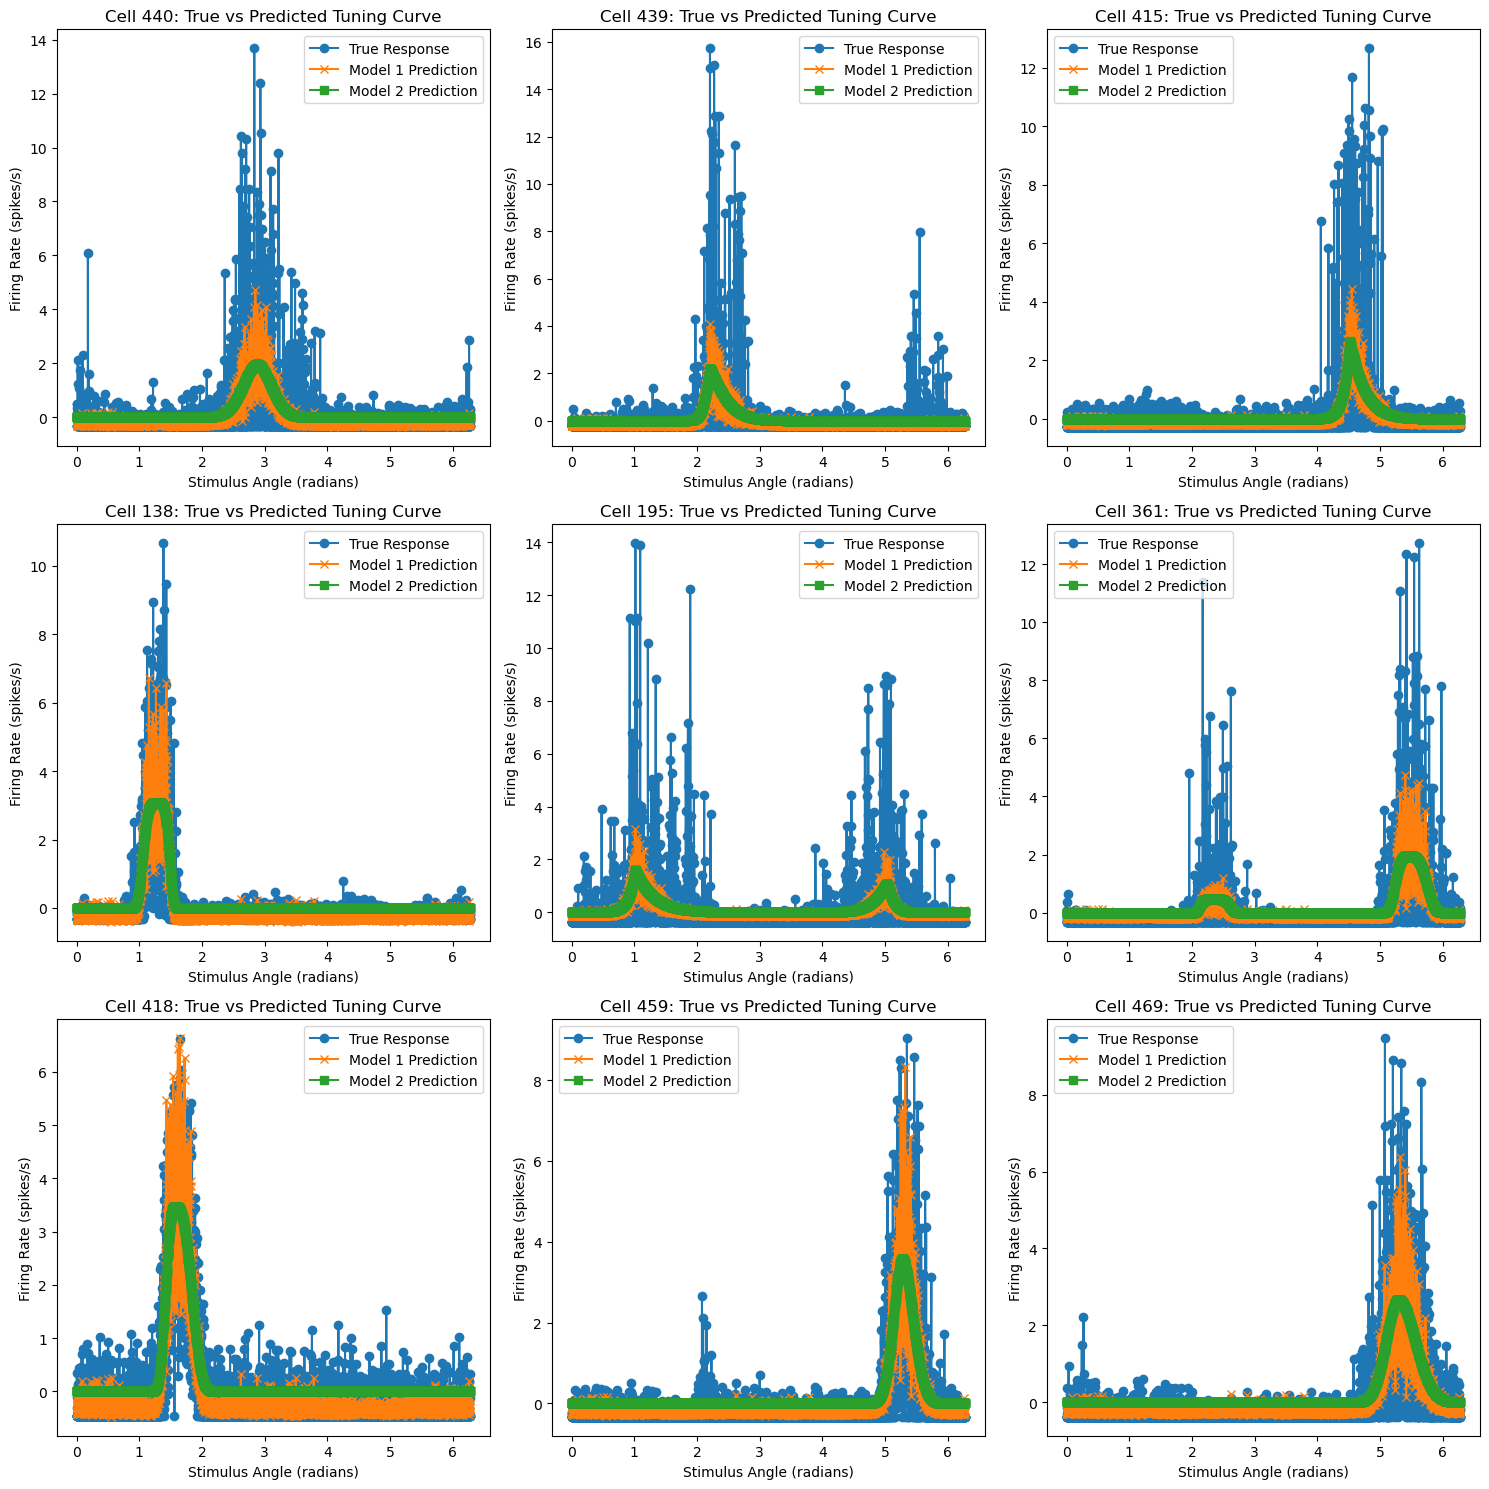

In [40]:
X_simple = {"stimulus": X['stimulus'], "response": X_train}
Y_pred_train_simple = model_simple(X_simple, params)

plot_model_fit(X_train_input['stimulus'], Y_train, pred_train, cell_idxs, Y_another_pred=Y_pred_train_simple)


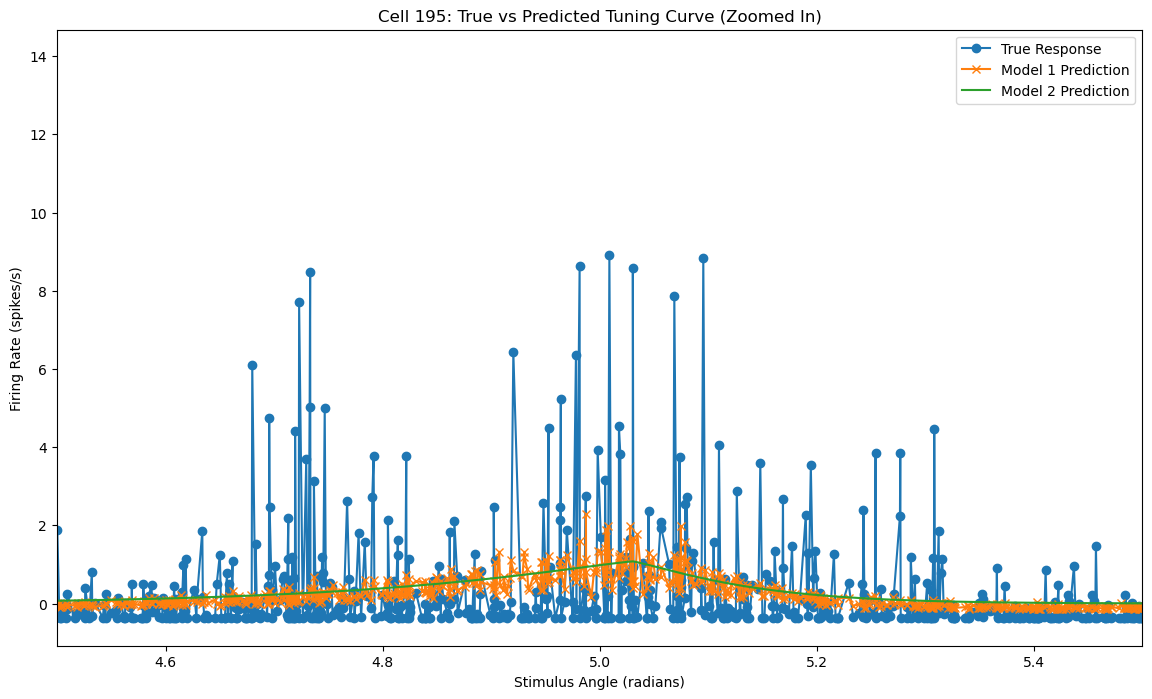

In [44]:
# plot a small region of cell 616
cell_idx = 195
plt.figure(figsize=(14, 8))
y_true = Y_train[cell_idx, :]
y_pred_v1 = pred_train[cell_idx, :]
y_pred_simple = Y_pred_train_simple[cell_idx, :]
angles = Y['stimulus'][0]
order = np.argsort(angles)
angles = angles[order]
y_true = y_true[order]
y_pred_v1 = y_pred_v1[order]
y_pred_simple = y_pred_simple[order]
plt.plot(angles, y_true.flatten(), label='True Response', marker='o')
plt.plot(angles, y_pred_v1.flatten(), label='Model 1 Prediction', marker='x')
plt.plot(angles, y_pred_simple.flatten(), label='Model 2 Prediction')
plt.xlabel('Stimulus Angle (radians)')
plt.ylabel('Firing Rate (spikes/s)')
plt.title(f'Cell {cell_idx}: True vs Predicted Tuning Curve (Zoomed In)')
# plt.xlim(0.8 * 2* np.pi, 2 * np.pi)
plt.xlim(4.5, 5.5)
plt.legend()
plt.show()

In [16]:
# compare the r^2 of the two models
def r_squared(y_true, y_pred):
    ss_res = jnp.sum((y_true - y_pred) ** 2)
    ss_tot = jnp.sum((y_true - jnp.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)


In [ ]:

r2_v1 = r_squared(Y_train, pred_train)
r2_simple = r_squared(Y_train, Y_pred_train_simple)

print(f"R^2 for model_v1: {r2_v1:.4f}")
print(f"R^2 for model_simple: {r2_simple:.4f}")

Cross-validated prediction

In [107]:
importlib.reload(project_spec)
from projects.trial_to_trial_variability.spec import load_and_process_data, train_test_split


In [108]:
# read the param values from the config yaml 
import yaml
with open('projects/trial_to_trial_variability/config.yaml', 'r') as f:
    config = yaml.safe_load(f)['data_processing_params']

data = load_and_process_data(**config)

X, Y = data

Filtering for orientation selectivity. Kept 649 out of 15166 cells.


In [116]:
def _build_train_test_split_fn(spec_train_test_split_fn):
    """
    Wrap spec.train_test_split so hypothesis_engine gets fully materialized
    sample+trial train/test indices.
    """
    def _wrapped_train_test_split_fn(inputs_3d: np.ndarray, random_seed: int):
        train_samples_raw, train_trials_raw = spec_train_test_split_fn(
            # Inputs.from_array(inputs_3d),
            inputs_3d,
            random_seed,
        )
        n_samples = int(inputs_3d.shape[0])
        n_trials = int(inputs_3d.shape[2])
        train_samples = np.asarray(train_samples_raw).reshape(-1).astype(np.int64, copy=False)
        train_trials = np.asarray(train_trials_raw).reshape(-1).astype(np.int64, copy=False)
        test_samples = np.setdiff1d(np.arange(n_samples, dtype=np.int64), train_samples, assume_unique=False)
        test_trials = np.setdiff1d(np.arange(n_trials, dtype=np.int64), train_trials, assume_unique=False)
        return train_samples, test_samples, train_trials, test_trials

    return _wrapped_train_test_split_fn
    
random_seed = 42
train_test_split_fn = _build_train_test_split_fn(train_test_split)
train_samples, test_samples, train_trials, test_trials = train_test_split_fn(X, random_seed=random_seed)

print(train_samples.size, test_samples.size, train_trials.size, test_trials.size)

1 1 2048 1027


In [117]:
print(train_samples, type(train_samples))
train_samples = np.asarray(train_samples).reshape(-1).astype(np.int64, copy=False)
print(train_samples, type(train_samples))

[0] <class 'numpy.ndarray'>
[0] <class 'numpy.ndarray'>


In [113]:
train_samples = np.asarray(train_samples).reshape(-1).astype(np.int64, copy=False)
test_samples = np.asarray(test_samples).reshape(-1).astype(np.int64, copy=False)
train_trials = np.asarray(train_trials).reshape(-1).astype(np.int64, copy=False)
test_trials = np.asarray(test_trials).reshape(-1).astype(np.int64, copy=False)

X_train_train_trials = X[train_samples][:, :, train_trials]
X_train_test_trials = X[train_samples][:, :, test_trials]
X_test_train_trials = X[test_samples][:, :, train_trials]
X_test_test_trials = X[test_samples][:, :, test_trials]

Y_train_train_trials = Y[train_samples][:, :, train_trials]
Y_train_test_trials = Y[train_samples][:, :, test_trials]
Y_test_train_trials = Y[test_samples][:, :, train_trials]
Y_test_test_trials = Y[test_samples][:, :, test_trials]

TypeError: Invalid key type: <class 'numpy.ndarray'>. Use int, str, or slice.

In [13]:
# I can Maybe fit the peakiness parameters from the training trials alone, and then I use those parameters to compare the prediction against the test trials 
# split the stimuli into train and test by randomly selecting 50% of the time points for training and the rest for testing.
n_time = X_stim.shape[1]
time_indices = np.arange(n_time)
random_seed = 42
rng = np.random.default_rng(random_seed)
rng.shuffle(time_indices)
train_indices = time_indices[:n_time // 2]
test_indices = time_indices[n_time // 2:]
train_stimuli = X_stim[:, train_indices]
test_stimuli = X_stim[:, test_indices]

source_cells_train_trials = jnp.array(X_train[:, train_indices]) # shape (n_source, n_time)
target_cells_train_trials = jnp.array(Y_train[:, train_indices]) # shape (n_target, n_time)

# Calculate the initial parameters for all source cells 
source_params_init = jax.vmap(parameter_estimator_jax)(train_stimuli, source_cells_train_trials) # shape (n_source, n_params)
# use gradient descent to optimise the parameters 
source_params = _optimize_params(source_params_init, train_stimuli, source_cells_train_trials) 

target_params_init = jax.vmap(parameter_estimator_jax)(train_stimuli, target_cells_train_trials) # shape (n_target, n_params)
target_params = _optimize_params(target_params_init, train_stimuli, target_cells_train_trials) 

# now calculate the predictions for the test trials using the optimised parameters from the train trials
source_cells_test_trials = jnp.array(X_train[:, test_indices]) # shape (n_source, n_time)
target_cells_test_trials = jnp.array(Y_train[:, test_indices]) # shape (n_target, n_time)
X_test_input = {"stimulus": test_stimuli, "response": source_cells_test_trials} # using the source cell responses from the test trials for prediction
Y_pred_test, multiplicative_gain, additive_offset, target_cell_coupling_factor = model_v1(X_test_input, {"source_tuning_params": source_params, "target_tuning_params": target_params, "target_cell_coupling_factor": jnp.ones(target_params.shape[0])})
Y_pred_test_simple = model_simple(X_test_input, {"source_tuning_params": source_params, "target_tuning_params": target_params, "target_cell_coupling_factor": jnp.ones(target_params.shape[0])})

DEBUG : (743, 2141), (743, 2141), (743, 11)
step  200  loss 0.6140
step  400  loss 0.6122
step  600  loss 0.6114
step  800  loss 0.6108
step 1000  loss 0.6103
step 1200  loss 0.6101
step 1400  loss 0.6099
step 1600  loss 0.6097
step 1800  loss 0.6097
step 2000  loss 0.6096
params optimized. Loss: 0.6096
DEBUG : (743, 2141), (743, 2141), (743, 11)
step  200  loss 0.6027
step  400  loss 0.6010
step  600  loss 0.6002
step  800  loss 0.5996
step 1000  loss 0.5993
step 1200  loss 0.5990
step 1400  loss 0.5988
step 1600  loss 0.5986
step 1800  loss 0.5985
step 2000  loss 0.5984
params optimized. Loss: 0.5984
Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
ALS converged at iteration 7. Error: 909.4775


In [27]:
optimised_target_cell_coupling_factor_lstsq.shape

(552049,)

In [39]:
# use gradient descent to optimise the coupling factor using the test trials
g_target_test = jax.vmap(lambda stim, params: neuron_model(stim, *params), in_axes=(0, 0))(test_stimuli, target_params).T # shape (n_time, n_target)
optimised_target_cell_coupling_factor = optimise_coupling_factors(jnp.ones(target_params.shape[0]), multiplicative_gain, additive_offset, g_target_test, target_cells_test_trials.T)

Y_pred_test_optimized, multiplicative_gain, additive_offset, target_cell_coupling_factor = model_v1(X_test_input, {"source_tuning_params": source_params, "target_tuning_params": target_params, "target_cell_coupling_factor": optimised_target_cell_coupling_factor})

# compare the r^2 of the two models on the test trials
r2_v1_test_optimized = r_squared(target_cells_test_trials, Y_pred_test_optimized)
r2_simple_test = r_squared(target_cells_test_trials, Y_pred_test_simple)
print(f"R^2 for model_v1 on test trials (optimized coupling): {r2_v1_test_optimized:.4f}")
print(f"R^2 for model_simple on test trials: {r2_simple_test:.4f}")


Iteration 0
Iteration 1
Iteration 2
Iteration 3
Iteration 4
Iteration 5
Iteration 6
Iteration 7
ALS converged at iteration 7. Error: 909.4775
R^2 for model_v1 on test trials (optimized coupling): 0.4714
R^2 for model_simple on test trials: 0.3970


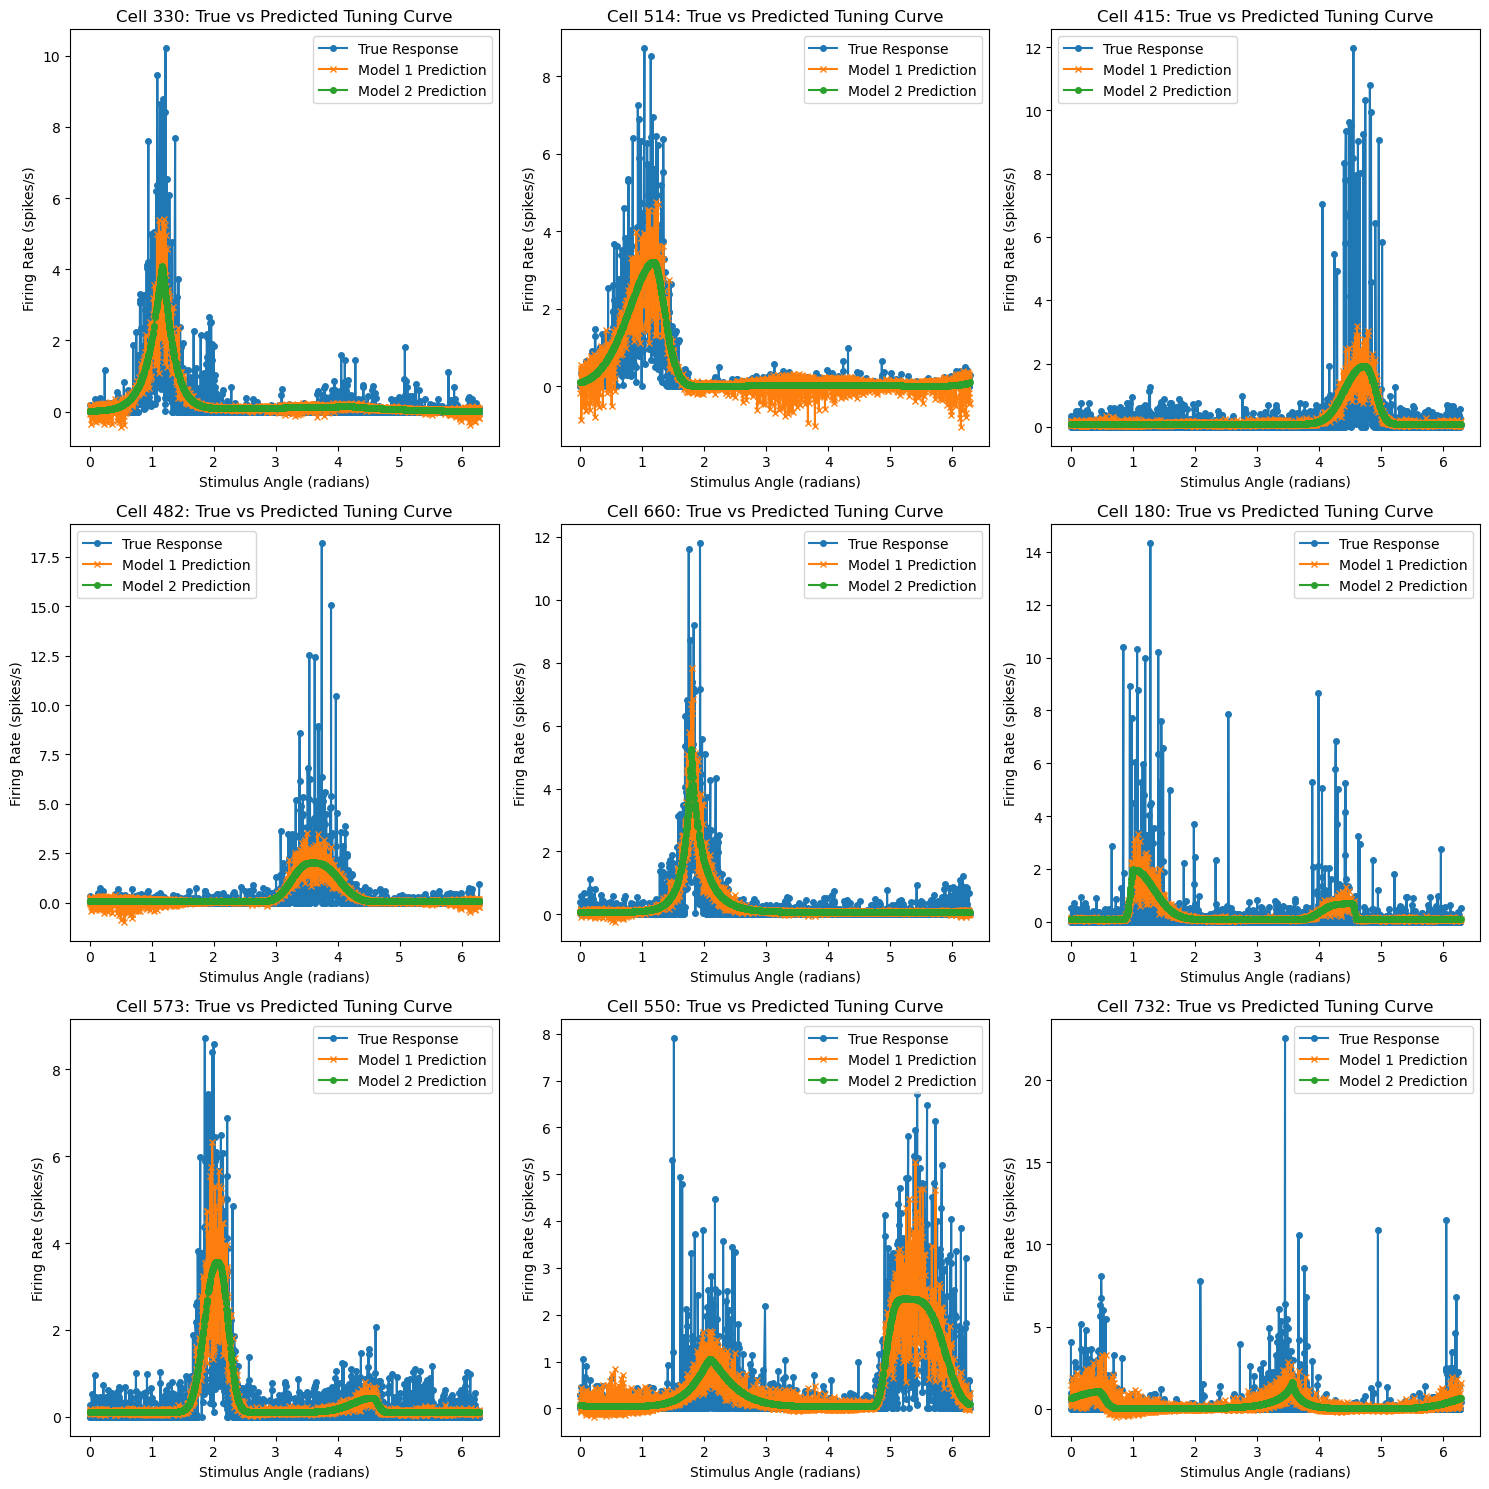

In [40]:
cell_idxs = np.random.choice(Y_train.shape[0], 9, replace=False)
plot_model_fit(test_stimuli, target_cells_test_trials, Y_pred_test_optimized, cell_idxs, Y_another_pred=Y_pred_test_simple)

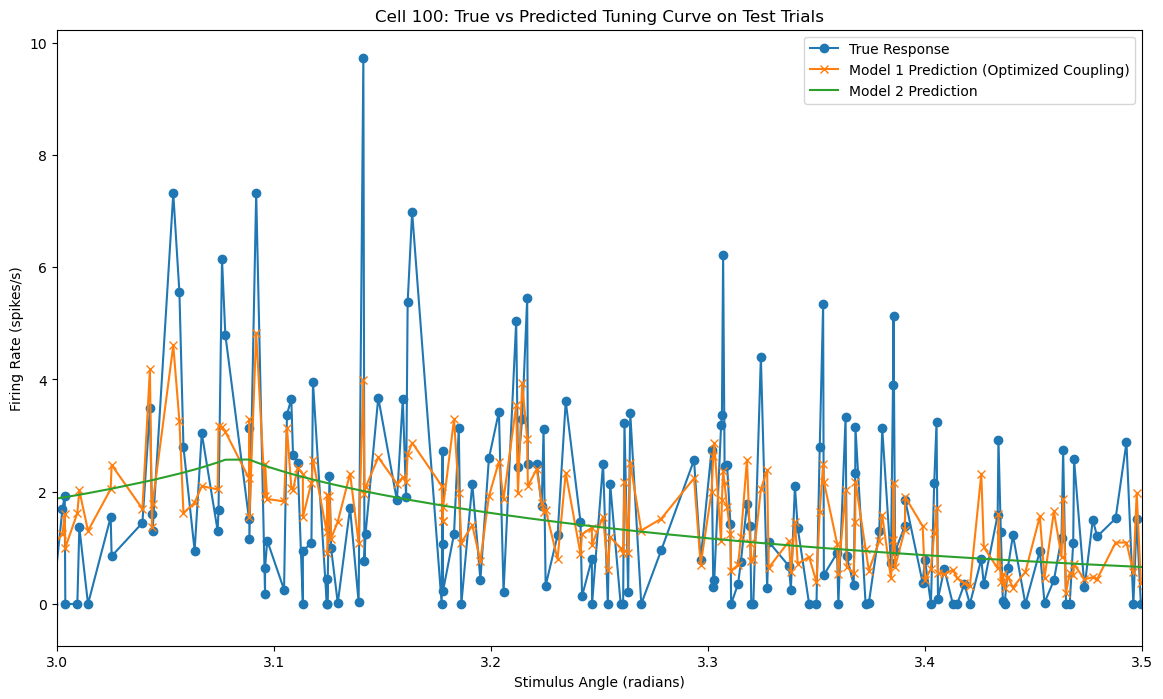

In [42]:
# zoom into single cell 
cell_idx = 100 
plt.figure(figsize=(14, 8))
y_true = target_cells_test_trials[cell_idx, :]
y_pred_v1_optimized = Y_pred_test_optimized[cell_idx, :]
y_pred_simple = Y_pred_test_simple[cell_idx, :]
angles = test_stimuli[0]
order = np.argsort(angles)
angles = angles[order]
y_true = y_true[order]
y_pred_v1_optimized = y_pred_v1_optimized[order]
y_pred_simple = y_pred_simple[order]
plt.plot(angles, y_true.flatten(), label='True Response', marker='o')
plt.plot(angles, y_pred_v1_optimized.flatten(), label='Model 1 Prediction (Optimized Coupling)', marker='x')
plt.plot(angles, y_pred_simple.flatten(), label='Model 2 Prediction')
plt.xlabel('Stimulus Angle (radians)')
plt.ylabel('Firing Rate (spikes/s)')
plt.title(f'Cell {cell_idx}: True vs Predicted Tuning Curve on Test Trials')
plt.legend()
plt.xlim(3, 3.5)
plt.show()

In [41]:
target_cells_test_trials = jnp.array(Y_train[:, test_indices]) # shape (n_target, n_time)
# order = np.argsort(test_stimuli[0, :])
order = np.argsort(X_stim[0, test_indices]) # sort by the original stimulus angles for better visualization

r2_v1_test = r_squared(target_cells_test_trials[:, order], Y_pred_test_optimized[:, order])
r2_simple_test = r_squared(target_cells_test_trials[:, order], Y_pred_test_simple[:, order])

print(f"R^2 for model_v1: {r2_v1_test:.4f}")
print(f"R^2 for model_simple: {r2_simple_test:.4f}")

R^2 for model_v1: 0.4714
R^2 for model_simple: 0.3970


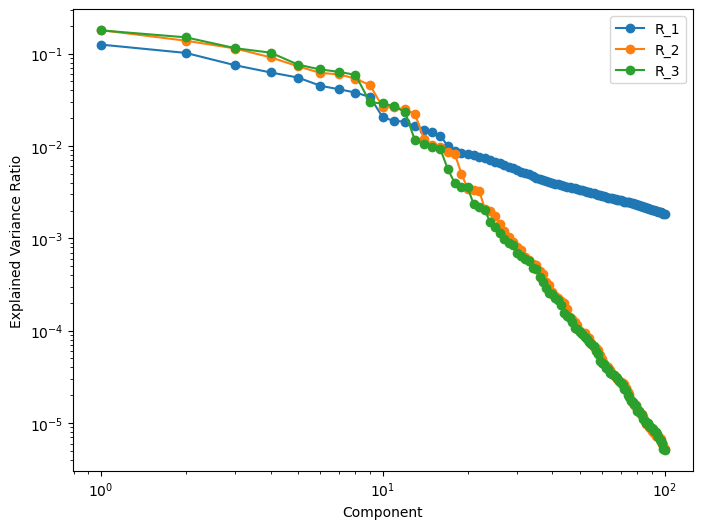

In [22]:
# PCA of 1. true response, 2. model_v1 prediction, 3. model_simple prediction for the test trials to see how they cluster in low dimensional space.
from sklearn.decomposition import PCA

n_components = 100
pca = PCA(n_components=n_components)

R_list = [target_cells_test_trials.T, Y_pred_test_optimized.T, Y_pred_test_simple.T]
eigvals = []
eigvecs = np.zeros((len(R_list), n_components, target_cells_test_trials.shape[0]))
for i, R in enumerate(R_list):
    pca.fit(R)
    explained_variance_ratio = pca.explained_variance_ratio_
    eigvals.append(explained_variance_ratio)
    eigvecs[i] = pca.components_

# loglog plot for the eigenspectra 
plt.figure(figsize=(8, 6))
for i, explained_variance_ratio in enumerate(eigvals):
    scaled_eigvals = explained_variance_ratio / (np.sum(explained_variance_ratio) + 1e-8)
    plt.loglog(np.arange(1, n_components + 1), scaled_eigvals, marker='o', label=f'R_{i+1}')
plt.xlabel('Component')
plt.ylabel('Explained Variance Ratio')
plt.legend()
plt.show()